In [1]:
# importing required libraries

import pandas as pd
import numpy as np

In [2]:
# loading the dataset

df = pd.read_csv("Maternal Health Risk Data Set.csv")

# checking dataset size
print(df.shape)

# seeing first few rows
print(df.head())

(1014, 7)
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk


In [3]:
# removing extra spaces from column names

df.columns = df.columns.str.strip()

print(df.columns)

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')


In [4]:
# removing duplicate rows if any

rows_before = df.shape[0]

df = df.drop_duplicates()

rows_after = df.shape[0]

print("Duplicates removed:", rows_before - rows_after)

Duplicates removed: 562


In [5]:
# making risk labels consistent

df["RiskLevel"] = df["RiskLevel"].str.strip().str.lower()

print(df["RiskLevel"].value_counts())

RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64


In [6]:
# making sure all health values are numeric

num_cols = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object


In [7]:
# checking if any missing values are present

print(df.isnull().sum())

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [8]:
# limiting extreme values using IQR method

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers handled")

Outliers handled


In [9]:
# final dataset check

print(df.shape)
print(df["RiskLevel"].value_counts())
print(df.describe())

(452, 7)
RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64
              Age  SystolicBP  DiastolicBP          BS  BodyTemp  HeartRate
count  452.000000  452.000000   452.000000  452.000000     452.0  452.00000
mean    29.064159  110.553097    75.418142    7.579358      98.0   74.05531
std     13.454295   17.872282    13.754578    0.961964       0.0    7.57514
min     10.000000   70.000000    49.000000    6.000000      98.0   55.00000
25%     19.000000   90.000000    65.000000    6.900000      98.0   70.00000
50%     25.000000  120.000000    80.000000    7.500000      98.0   76.00000
75%     35.000000  120.000000    86.000000    7.900000      98.0   80.00000
max     59.000000  160.000000   100.000000    9.400000      98.0   90.00000


In [10]:
# importing libraries for visualization

import matplotlib.pyplot as plt
import seaborn as sns

# basic statistical summary

print(df.describe())

# checking class distribution
print(df["RiskLevel"].value_counts())

              Age  SystolicBP  DiastolicBP          BS  BodyTemp  HeartRate
count  452.000000  452.000000   452.000000  452.000000     452.0  452.00000
mean    29.064159  110.553097    75.418142    7.579358      98.0   74.05531
std     13.454295   17.872282    13.754578    0.961964       0.0    7.57514
min     10.000000   70.000000    49.000000    6.000000      98.0   55.00000
25%     19.000000   90.000000    65.000000    6.900000      98.0   70.00000
50%     25.000000  120.000000    80.000000    7.500000      98.0   76.00000
75%     35.000000  120.000000    86.000000    7.900000      98.0   80.00000
max     59.000000  160.000000   100.000000    9.400000      98.0   90.00000
RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64


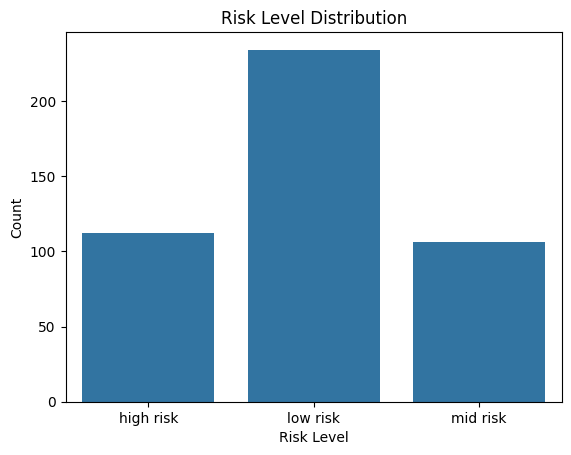

In [11]:
# count plot for risk levels

plt.figure()
sns.countplot(x="RiskLevel", data=df)
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

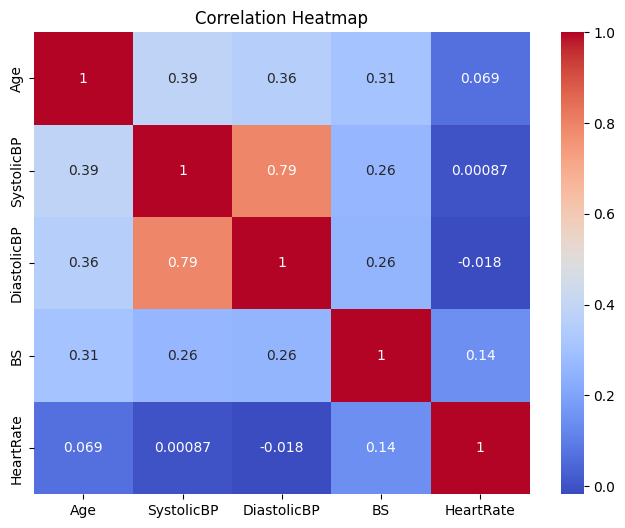

In [12]:
# ---- Correlation Heatmap ----

plt.figure(figsize=(8,6))

# take only numeric columns
num_df = df.select_dtypes(include=["int64","float64"])

# remove columns which have only one unique value
# (constant columns like BodyTemp)
num_df = num_df.loc[:, num_df.nunique() > 1]

# calculate correlation
corr = num_df.corr()

# plot heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

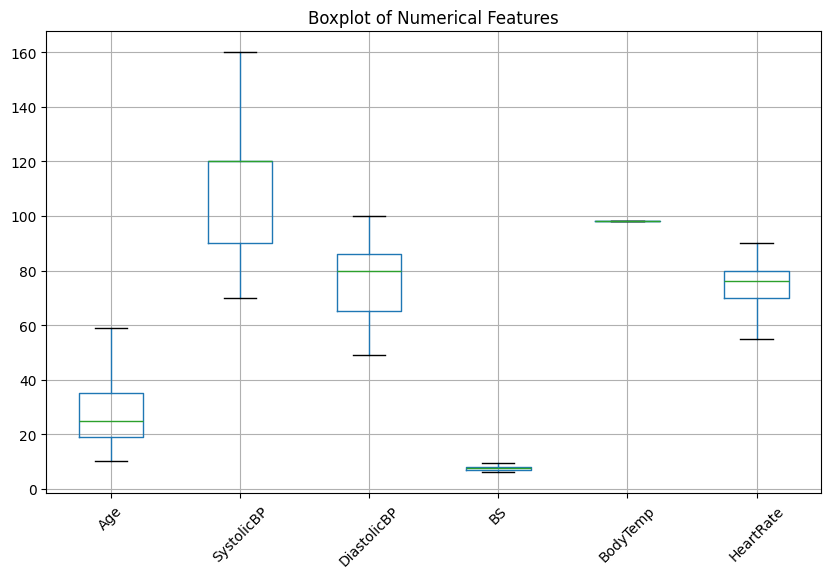

In [13]:
# boxplot for all numeric features

plt.figure(figsize=(10,6))

df.boxplot()

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

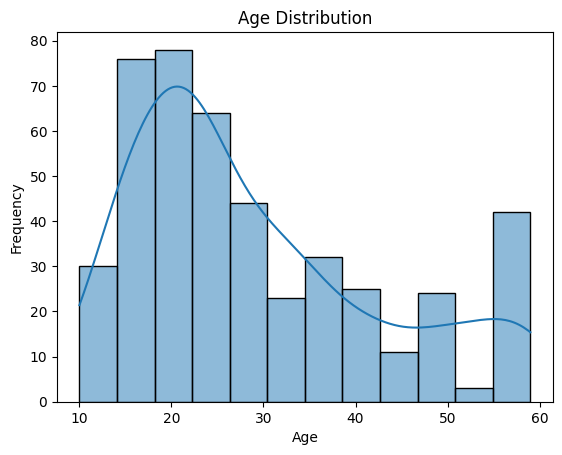

In [14]:
# distribution of Age

plt.figure()

sns.histplot(df["Age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

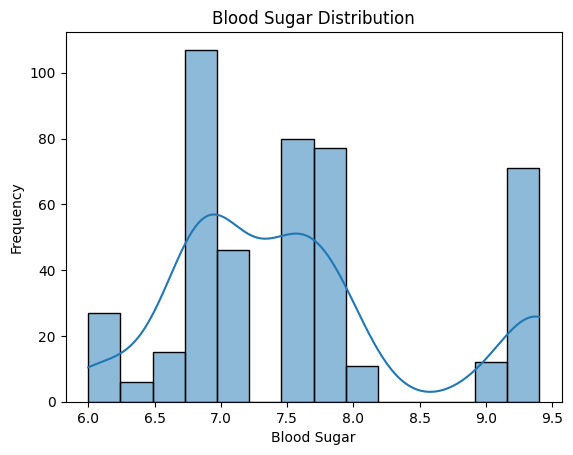

In [15]:
# distribution of Blood Sugar

plt.figure()

sns.histplot(df["BS"], kde=True)

plt.title("Blood Sugar Distribution")
plt.xlabel("Blood Sugar")
plt.ylabel("Frequency")
plt.show()

In [16]:
# separating input and output

X = df.drop("RiskLevel", axis=1)
y = df["RiskLevel"]

print(X.shape)
print(y.shape)

(452, 6)
(452,)


In [17]:
# removing body temperature column

X = X.drop("BodyTemp", axis=1)

In [18]:
# converting text labels to numbers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

# check encoded values
print(y[:10])

[0 0 0 0 1 0 2 0 2 0]


In [19]:
# splitting dataset into training and testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,
    stratify=y          # keeps class ratio same
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (361, 5)
Test size: (91, 5)


In [20]:
# scaling feature values

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# learn scaling from training data
X_train = scaler.fit_transform(X_train)

# apply same scaling to test data
X_test = scaler.transform(X_test)

In [21]:
# balancing classes using SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# apply only on training data
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train.shape)

After SMOTE: (561, 5)


In [22]:
# importing required libraries for models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# creating model
dt_model = DecisionTreeClassifier(
    criterion="gini",      # how splits are decided
    max_depth=5,           # limits tree height (prevents overfitting)
    min_samples_split=5,   # minimum samples required to split a node
    min_samples_leaf=2,    # minimum samples in leaf node
    random_state=42
)

# training
dt_model.fit(X_train, y_train)

# prediction
dt_pred = dt_model.predict(X_test)

# results
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.6813186813186813
              precision    recall  f1-score   support

           0       0.94      0.65      0.77        23
           1       0.63      0.98      0.77        47
           2       0.50      0.05      0.09        21

    accuracy                           0.68        91
   macro avg       0.69      0.56      0.54        91
weighted avg       0.68      0.68      0.61        91



In [23]:
# Artificial Neural Network (ANN)

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# creating model
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 hidden layers
    activation="relu",            # activation function
    solver="adam",                # optimizer
    max_iter=500,                 # maximum iterations
    random_state=42
)

# training
ann_model.fit(X_train, y_train)

# prediction
ann_pred = ann_model.predict(X_test)

# results
print("ANN Accuracy:", accuracy_score(y_test, ann_pred))
print(classification_report(y_test, ann_pred))

ANN Accuracy: 0.5934065934065934
              precision    recall  f1-score   support

           0       0.88      0.65      0.75        23
           1       0.64      0.64      0.64        47
           2       0.33      0.43      0.38        21

    accuracy                           0.59        91
   macro avg       0.62      0.57      0.59        91
weighted avg       0.63      0.59      0.61        91



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [24]:
# XGBoost Classifier

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# creating model
xgb_model = XGBClassifier(
    n_estimators=200,      # number of trees
    learning_rate=0.1,     # step size
    max_depth=4,           # tree depth
    subsample=0.9,         # row sampling
    colsample_bytree=0.9,  # feature sampling
    objective="multi:softmax",  # multi-class classification
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

# training
xgb_model.fit(X_train, y_train)

# prediction
xgb_pred = xgb_model.predict(X_test)

# results
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.6153846153846154
              precision    recall  f1-score   support

           0       0.89      0.70      0.78        23
           1       0.67      0.72      0.69        47
           2       0.27      0.29      0.28        21

    accuracy                           0.62        91
   macro avg       0.61      0.57      0.58        91
weighted avg       0.63      0.62      0.62        91



In [25]:
# evaluation plotting libraries

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# converting test labels to binary format for ROC curve

import numpy as np

classes = [0,1,2]   # low, mid, high
y_test_bin = label_binarize(y_test, classes=classes)

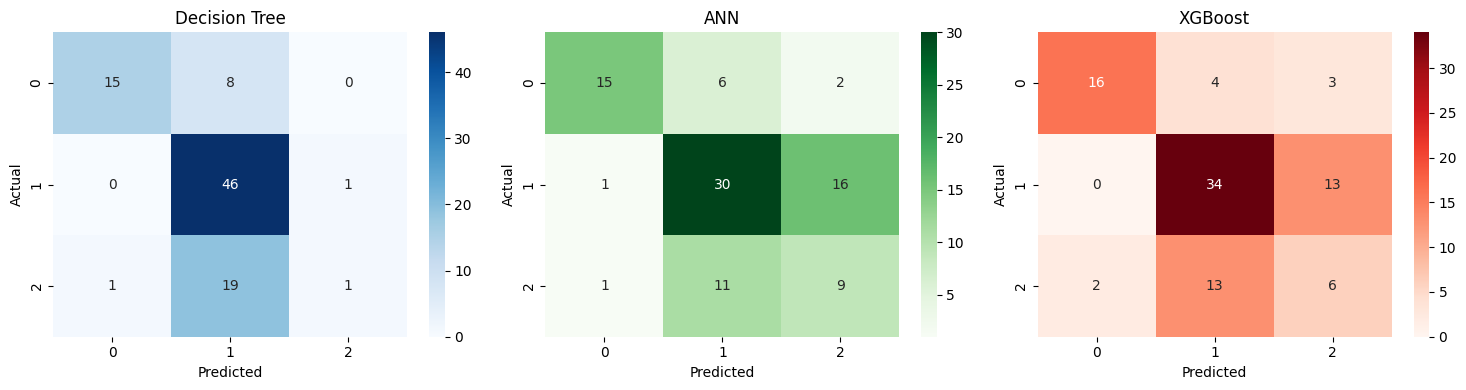

In [26]:
# Confusion matrices for all models in one place

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(15,4))

# ---- Decision Tree ----
plt.subplot(1,3,1)
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# ---- ANN ----
plt.subplot(1,3,2)
cm_ann = confusion_matrix(y_test, ann_pred)
sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Greens")
plt.title("ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# ---- XGBoost ----
plt.subplot(1,3,3)
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds")
plt.title("XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

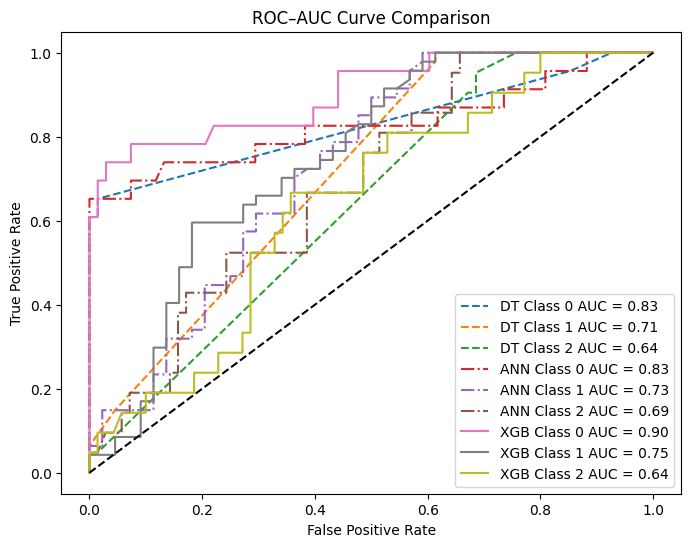

In [27]:
# ROC–AUC curves for all models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# convert y_test into binary format (needed for multi-class ROC)
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

# ---------- Decision Tree ----------
dt_probs = dt_model.predict_proba(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], dt_probs[:, i])
    plt.plot(fpr, tpr, linestyle="--", label=f"DT Class {i} AUC = {auc(fpr, tpr):.2f}")

# ---------- ANN ----------
ann_probs = ann_model.predict_proba(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], ann_probs[:, i])
    plt.plot(fpr, tpr, linestyle="-.", label=f"ANN Class {i} AUC = {auc(fpr, tpr):.2f}")

# ---------- XGBoost ----------
xgb_probs = xgb_model.predict_proba(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], xgb_probs[:, i])
    plt.plot(fpr, tpr, label=f"XGB Class {i} AUC = {auc(fpr, tpr):.2f}")

# diagonal reference line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve Comparison")
plt.legend()
plt.show()

In [28]:
# tuning Decision Tree using GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best Decision Tree CV Accuracy:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_

Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Decision Tree CV Accuracy: 0.7255689001264223


In [29]:
# tuning ANN using GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(random_state=42, max_iter=500)

ann_params = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (100,)],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate": ["constant", "adaptive"]
}

ann_grid = GridSearchCV(
    estimator=ann,
    param_grid=ann_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

ann_grid.fit(X_train, y_train)

print("Best ANN Params:", ann_grid.best_params_)
print("Best ANN CV Accuracy:", ann_grid.best_score_)

best_ann = ann_grid.best_estimator_

Best ANN Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'constant', 'solver': 'adam'}
Best ANN CV Accuracy: 0.705862831858407


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [30]:
# tuning XGBoost using GridSearchCV

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_grid.best_params_)
print("Best XGBoost CV Accuracy:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_

Best XGBoost Params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best XGBoost CV Accuracy: 0.7505689001264223


In [31]:
# testing tuned models on test set
dt_test_pred = best_dt.predict(X_test)
ann_test_pred = best_ann.predict(X_test)
xgb_test_pred = best_xgb.predict(X_test)

In [32]:
from sklearn.metrics import classification_report

# Decision Tree
print("===== Decision Tree Classification Report =====")
print(classification_report(y_test, dt_test_pred))

# ANN
print("===== ANN Classification Report =====")
print(classification_report(y_test, ann_test_pred))

# XGBoost
print("===== XGBoost Classification Report =====")
print(classification_report(y_test, xgb_test_pred))

===== Decision Tree Classification Report =====
              precision    recall  f1-score   support

           0       0.77      0.74      0.76        23
           1       0.67      0.55      0.60        47
           2       0.27      0.38      0.31        21

    accuracy                           0.56        91
   macro avg       0.57      0.56      0.56        91
weighted avg       0.60      0.56      0.58        91

===== ANN Classification Report =====
              precision    recall  f1-score   support

           0       0.88      0.65      0.75        23
           1       0.64      0.64      0.64        47
           2       0.33      0.43      0.38        21

    accuracy                           0.59        91
   macro avg       0.62      0.57      0.59        91
weighted avg       0.63      0.59      0.61        91

===== XGBoost Classification Report =====
              precision    recall  f1-score   support

           0       0.94      0.70      0.80        23
 